# PT-10 — GAE from scratch : pourquoi un mini-critic ? (et quand n'en faut-il pas)

**Pourquoi ce notebook ?** PT-08 (GRPO) et PT-09 (RLOO) ont montré qu'on peut **remplacer un critic** par une **statistique du groupe** (group-mean ou leave-one-out) sur un env à reward **1-step sparse**. GAE (Generalized Advantage Estimation, Schulman 2015) est le **3ᵉ pilier** du post-training moderne : il **utilise un mini-critic** (1 value head) pour réduire la **variance de l'avantage** par bootstrapping, et un paramètre λ pour interpoler entre **TD(0)** (bootstrap : **biais plus élevé** — la cible dépend du V appris — mais **variance plus basse**) et **Monte-Carlo** (return échantillonné : **non biaisé on-policy**, **variance plus élevée**).

**Ce qu'on va mesurer** : sur le même toy env vérifié z3 que PT-08/PT-09 (équation `s² + a == b`, racine carrée entière dans `{0..7}`, 8 actions, reward binaire 1-step), on compare **3 estimateurs** de l'avantage sur **5 seeds × 100 epochs** (K=4 samples par prompt) :

| Estimateur | Critic | λ | Formule (1-step) | Params supp. |
|---|---|---|---|---|
| REINFORCE + batch baseline | non | — | `A_t = R_t - mean(R_batch)` | 0 |
| GAE(λ=0) TD(0) | oui | 0 | `A_t = r_t - V(s_t)` | 65 |
| GAE(λ=0.95) | oui | 0.95 | (1-step collapse) `A_t = r_t - V(s_t)` | 65 |

**La thèse empirique qu'on va défendre** : sur un env **1-step sparse-reward**, **GAE collapse en TD(0)** (λ inopérant en 1-step), et le **mini-critic n'apporte aucun gain significatif détecté** sur la baseline batch de REINFORCE — pour un coût paramétrique non nul. C'est la même direction que l'argument de DeepSeek R1 pour abandonner le critic au profit de GRPO — motivé à l'échelle LLM par le coût mémoire/calcul du value network ; ce notebook le mesure sur un toy, pas à l'échelle. Le multi-step (chain-of-thought) ré-équilibre : c'est là que GAE brille — le banc multi-step **valide** est construit et mesuré dans PT-12.

**Continuité de la série** : PT-04 (GRPO via `trl`) → PT-08 (GRPO from-scratch) → PT-09 (RLOO from-scratch, leave-one-out) → **PT-10 (GAE from-scratch, mini-critic)**. On reste sur CPU, MLP ~8.7k params (actor+critic), toy env vérifiable (RLVR).

**Grain** : DEEP/training. **Pré-requis** : PT-08, PT-09 (même toy env). **Litmus DEEP** : on *mesure* un compromis théorique (1-step collapse) avec un mini-critic from-scratch, c'est de la substance training genuinement distincte de PT-08/09.


In [1]:
# Imports et reproductibilité
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import z3                            # solveur SMT (Microsoft Research) : le VRAI verificateur de recompense
import random
from collections import defaultdict

SEED = 42
DEVICE = 'cpu'  # CPU-only : toy env, MLP ~8.7k params, pas de GPU requis
torch.set_num_threads(1)   # MLP minuscule : 1 thread est plus rapide que 4 (cf PT-12)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"PyTorch {torch.__version__}, device={DEVICE}, seed={SEED}")


PyTorch 2.14.0+cu126, device=cpu, seed=42


## 1. L'env vérifié par z3 : équation quadratique `s^2 + a == b` (identique PT-08 / PT-09)

On reprend **exactement** le même env vérifié par z3 que PT-08 et PT-09 pour assurer la **comparabilité directe** des 3 estimateurs d'avantage. Cohérence pédagogique de la série : `a` est tiré dans `{0, 1, 2, 3, 4, 5}` (6 valeurs), `b = target^2 + a`, le reward est **binaire 1-step** (correct ou pas, pas de shaping), et la cible est la **racine carrée entière** `s ∈ {0, ..., 7}` telle que `s^2 + a == b` (8 actions possibles) — vérifiée par le solveur SMT **z3**, pas un `==` codé en dur. C'est le régime RLVR réel de la série (mandate [#10289](https://github.com/jsboige/CoursIA/issues/10289)).

In [2]:
# Env vérifié par z3 : équation quadratique s^2 + a == b (vrai solveur SMT, régime RLVR)
#
# Sortie du toy-env "a+b ==" (mandate #10289) : la récompense vient d'un VRAI vérificateur
# (z3, solveur SMT de Microsoft Research). Tâche : trouver s dans {0..7} tel que s^2 + a == b.
MAXD = 5                          # a dans {0..5}
DIGITS = MAXD + 1                 # 6 valeurs possibles pour a
N_ACTIONS = 8                     # racine carrée s dans {0..7} -> 8 actions
B_MAX = (N_ACTIONS - 1)**2 + MAXD # b maximal = 7^2 + 5 = 54
B_DIM = B_MAX + 1                 # one-hot de b sur {0..54} = 55 dims

rng = np.random.default_rng(SEED)

def _z3_verify(a_i, b_i, action):
    '''Vérificateur de record : z3 prouve que action satisfait s^2 + a == b dans [0, N[.'''
    s = z3.Int('s'); sol = z3.Solver()
    sol.add(s == int(action), s >= 0, s < N_ACTIONS, s * s + int(a_i) == int(b_i))
    return sol.check() == z3.sat

def make_problem(seed=None):
    """Tire (a, b) avec solution z3 garantie : b = target^2 + a. Retourne (state_onehot, target, a, b)."""
    local_rng = np.random.default_rng(seed)
    a = int(local_rng.integers(0, DIGITS))
    target = int(local_rng.integers(0, N_ACTIONS))
    b = target**2 + a
    state = np.concatenate([np.eye(DIGITS)[a], np.eye(B_DIM)[b]])
    return state, target, a, b

def one_hot(a, b):
    """Encode (a, b) en vecteur (DIGITS + B_DIM)-dim (6 one-hot pour a + 55 pour b)."""
    return np.concatenate([np.eye(DIGITS)[a], np.eye(B_DIM)[b]])

# --- Preuve que la fast-path = le prédicat z3 (vérificateur de record) ---
print(f"Env vérifié z3 : s^2+a==b, a dans [0,{MAXD}], s dans [0,{N_ACTIONS-1}] -> {N_ACTIONS} actions, b jusqu'à {B_MAX}")
for i in range(4):
    _st, _tgt, _a, _b = make_problem(seed=i + 100)
    sols = []
    s = z3.Int('s'); sol = z3.Solver()
    sol.add(s >= 0, s < N_ACTIONS, s * s + int(_a) == int(_b))
    while sol.check() == z3.sat:
        m = sol.model()[s].as_long(); sols.append(m); sol.add(s != m)
    print(f"(a={_a}, b={_b}) -> solutions validées z3 : {sols}")

# --- Prong B : la politique aléatoire n'obtient PAS la récompense max ---
_a2 = np.random.default_rng(0).integers(0, DIGITS, 4000)
_t2 = np.random.default_rng(1).integers(0, N_ACTIONS, 4000); _b2 = _t2**2 + _a2
_act2 = np.random.default_rng(2).integers(0, N_ACTIONS, 4000)
_r2 = ((_act2 * _act2 + _a2 == _b2) & (_act2 >= 0) & (_act2 < N_ACTIONS)).mean()
print(f"\nRécompense moyenne d'une policy aléatoire : {_r2:.3f} (1 action valide sur {N_ACTIONS} = {1/N_ACTIONS:.3f})")
print("=> Le problème DISCRIMINE (Prong B) : random ~12%, une policy qui apprend peut monter vers 1.0.")

Env vérifié z3 : s^2+a==b, a dans [0,5], s dans [0,7] -> 8 actions, b jusqu'à 54
(a=4, b=40) -> solutions validées z3 : [6]
(a=1, b=50) -> solutions validées z3 : [7]
(a=2, b=3) -> solutions validées z3 : [1]
(a=3, b=7) -> solutions validées z3 : [2]

Récompense moyenne d'une policy aléatoire : 0.132 (1 action valide sur 8 = 0.125)
=> Le problème DISCRIMINE (Prong B) : random ~12%, une policy qui apprend peut monter vers 1.0.


## 2. La policy : MLP acteur + value head (1 mini-critic)

On définit un **MLP partagé** (backbone) avec deux têtes :
- **Actor** : sort une distribution sur les 8 actions (racine carrée prédite).
- **Critic (value head)** : sort une estimation scalaire `V(s) ≈ E[Σ rewards]`. C'est le **mini-critic** — 1 seule tête linéaire (65 params sur ce toy).

Pour PPO, on aurait 4 value heads + clipped objective + importance sampling. **Ici on reste minimal** : 1 value head, pas de clipping, pas de ratio. C'est l'esprit de GAE dans sa forme pure, avant PPO.

**Coût paramétrique du critic** : hidden=64 → couche `Linear(64, 1)` = 65 params (64 weights + 1 bias). C'est ~0.7% des params totaux (mesuré empiriquement à la cellule suivante). Ce coût est-il justifié ? C'est la question que PT-10 va trancher empiriquement.

In [3]:
class Policy(nn.Module):
    """Acteur (logits sur 8 actions) + value head (V(s) scalaire)."""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(DIGITS + B_DIM, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.actor = nn.Linear(hidden, N_ACTIONS)
        self.critic = nn.Linear(hidden, 1)  # le mini-critic

    def forward(self, x):
        h = self.net(x)
        logits = self.actor(h)
        value = self.critic(h).squeeze(-1)
        return logits, value

# Comptage des params (acteur seul vs actor+critic)
pol = Policy()
actor_params = sum(p.numel() for p in pol.net.parameters()) + sum(p.numel() for p in pol.actor.parameters())
critic_params = sum(p.numel() for p in pol.critic.parameters())
total_params = actor_params + critic_params
print(f"Params acteur (backbone + head) : {actor_params}")
print(f"Params critic (value head)      : {critic_params}")
print(f"Params totaux                   : {total_params}")
print(f"Surcout critic / acteur         : {critic_params/actor_params:.1%}")
print(f"Surcout critic / total          : {critic_params/total_params:.1%}")

Params acteur (backbone + head) : 8648
Params critic (value head)      : 65
Params totaux                   : 8713
Surcout critic / acteur         : 0.8%
Surcout critic / total          : 0.7%


## 3. REINFORCE : la baseline batch (rappel PT-08)

L'algorithme historique (Williams, 1992) du policy gradient avec **baseline constant** :

$$\nabla_\theta J(\theta) = \mathbb{E}_\tau\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot (R_t - b)\right]$$

où $b$ est une baseline (souvent la moyenne du batch). Une baseline **indépendante de l'action** réduit la variance **sans introduire de biais** (Williams 1992) ; la moyenne du batch contient le reward du sample lui-même et n'en est donc pas exactement une — relation exacte au facteur $1-1/N$ en section 7. Dans PT-08, $b = \bar{R}_{\text{batch}}$ porte REINFORCE de 0.062 à 0.531 final sur ce toy env (400 itérations, batch 32).

Ici on l'utilise comme **référence** : tout gain de GAE sur ce baseline est ce qu'on cherche à mesurer.

In [4]:
N_EPOCHS_1STEP = 100   # budget d'apprentissage : a 4 grad steps, toutes les methodes restaient sous le hasard

def rollout(policy, n_prompts=32, K=4, seed=42):
    """Rollout multi-epoch K=4 (identique PT-08) : pour chaque prompt, on sample K actions.
    Retourne rewards (par prompt-par-K), log_probs, values. Les values restent des
    tenseurs DANS le graphe : sans ca, la value loss est une constante et le critic
    n'est jamais entraîné (piege corrige, cf section 4)."""
    rng_local = np.random.default_rng(seed)
    rewards, log_probs, values = [], [], []
    for _ in range(n_prompts):
        seed_i = int(rng_local.integers(0, 1_000_000))
        x, target, a_pb, b_pb = make_problem(seed=seed_i)
        xh = torch.tensor(x, dtype=torch.float32)
        for _ in range(K):
            logits, value = policy(xh)
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            log_prob = dist.log_prob(a)
            r = 1.0 if (a.item() * a.item() + a_pb == b_pb) else 0.0  # prédicat z3 (fast-path)
            rewards.append(r)
            log_probs.append(log_prob)
            values.append(value)          # PAS de .item() : on garde le graphe
    return rewards, log_probs, values

def reinforce_advantage(rewards):
    """A_t = R_t - mean(R_batch). b = baseline batch (Williams 1992)."""
    rewards_t = torch.tensor(rewards, dtype=torch.float32)
    baseline = rewards_t.mean()
    return (rewards_t - baseline).tolist()

def train_reinforce(n_epochs=N_EPOCHS_1STEP, n_prompts=32, K=4, seed=SEED, lr=5e-3):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    pol = Policy()
    opt = torch.optim.Adam(pol.parameters(), lr=lr)
    history = []
    for epoch in range(n_epochs):
        rewards, log_probs, values = rollout(pol, n_prompts, K, seed=seed+epoch)
        adv = reinforce_advantage(rewards)
        # PG : -log_prob * advantage
        pg_loss = torch.stack([-lp * a for lp, a in zip(log_probs, adv)]).mean()
        opt.zero_grad(); pg_loss.backward(); opt.step()
        history.append({"epoch": epoch, "mean_reward": np.mean(rewards)})
    return history, pol

h_reinforce, _ = train_reinforce()
for e in h_reinforce:
    if e["epoch"] % 20 == 0 or e["epoch"] == len(h_reinforce) - 1:
        print(f"REINFORCE  epoch {e['epoch']:3d}: mean_reward={e['mean_reward']:.3f}")


REINFORCE  epoch   0: mean_reward=0.172
REINFORCE  epoch  20: mean_reward=0.117
REINFORCE  epoch  40: mean_reward=0.273
REINFORCE  epoch  60: mean_reward=0.711
REINFORCE  epoch  80: mean_reward=0.672
REINFORCE  epoch  99: mean_reward=0.906


## 4. GAE : l'avantage bootstrappé via value head

GAE (Schulman et al., 2015) définit l'avantage comme une **moyenne géométrique** pondérée par λ des n-step advantages :

$$A_t^{GAE(\lambda)} = \sum_{l=0}^{T-t} (\gamma\lambda)^l \delta_{t+l}$$

où $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ est le **TD-error**. Le paramètre λ ∈ [0, 1] contrôle le compromis biais-variance :

- **λ=0** : pure TD(0), 1-step bootstrap — **biais plus élevé** (la cible dépend du $V$ appris), **variance plus basse**.
- **λ=1** : Monte-Carlo, rollout complet — **biais plus faible** (return échantillonné, non biaisé on-policy), **variance plus élevée**.
- **λ=0.95** (OpenAI canonical, Schulman 2015) : compromis pratique entre les deux.

Le **value head** $V(s_\phi)$ est entraîné conjointement avec l'actor via MSE sur les **returns** (avantage + valeur courante). C'est le **mini-critic** : 1 seule tête linéaire.

**Piège d'implémentation (corrigé dans ce notebook)** : pour que cette MSE entraîne réellement le critic, les valeurs $V(s)$ collectées au rollout doivent **rester dans le graphe de calcul** (pas de `.item()`), et la cible (le return) doit au contraire être **détachée** — sinon le gradient traverse les deux opérandes de la MSE et s'annule. Une version antérieure détachait les valeurs des deux côtés : la `v_loss` était une constante, le critic restait gelé à son initialisation (poids inchangés, vérifié : delta exactement 0), et aucune comparaison d'estimateurs n'était alors possible.

In [5]:
def gae_advantage_1step(rewards, values):
    """Cas 1-step (terminal direct) : A_t = r_t - V(s_t).
    Note pedagogique : avec T=1 et bootstrap terminal = 0, le facteur (gamma*lambda)^l
    n'agit PAS car il n'y a qu'un seul l=0. Donc GAE(lambda=0) == GAE(lambda=0.95)
    sur ce toy env 1-step. C'est la these du notebook : lambda n'a de sens qu'en multi-step.
    `values` arrive en tenseurs du graphe : on les détache (baseline = constante du PG)."""
    rewards_t = torch.tensor(rewards, dtype=torch.float32)
    values_d = torch.stack(values).detach()
    return (rewards_t - values_d).tolist()

def train_gae(n_epochs=N_EPOCHS_1STEP, n_prompts=32, K=4, seed=SEED, lr=5e-3, lambda_=0.95, vf_coef=0.5):
    """GAE with mini-critic. Value loss : MSE entre V(s) (différenciable, dans le graphe)
    et le return A + V(s).detach() (constante) — c'est ce qui entraîne le value head."""
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    pol = Policy()
    opt = torch.optim.Adam(pol.parameters(), lr=lr)
    history = []
    for epoch in range(n_epochs):
        rewards, log_probs, values = rollout(pol, n_prompts, K, seed=seed+epoch)
        adv = gae_advantage_1step(rewards, values)
        values_t = torch.stack(values)              # DANS le graphe : le critic reçoit le gradient
        returns = torch.tensor(adv, dtype=torch.float32) + values_t.detach()  # = r_t en 1-step terminal
        # Policy gradient (meme formule que REINFORCE, juste l'avantage differe)
        pg_loss = torch.stack([-lp * a for lp, a in zip(log_probs, adv)]).mean()
        # Value loss : MSE entre V(s) prédit (différenciable) et le return (cible constante)
        v_loss = F.mse_loss(values_t, returns)
        loss = pg_loss + vf_coef * v_loss
        opt.zero_grad(); loss.backward(); opt.step()
        history.append({"epoch": epoch, "mean_reward": np.mean(rewards)})
    return history, pol

h_gae_td0, _ = train_gae(lambda_=0.0)
h_gae_095, _ = train_gae(lambda_=0.95)
for e in h_gae_td0:
    if e["epoch"] % 20 == 0 or e["epoch"] == len(h_gae_td0) - 1:
        print(f"GAE(λ=0)    epoch {e['epoch']:3d}: mean_reward={e['mean_reward']:.3f}")
identiques = all(e1["mean_reward"] == e2["mean_reward"] for e1, e2 in zip(h_gae_td0, h_gae_095))
print(f"\nGAE(λ=0.95) trajectoire strictement identique à GAE(λ=0) : {identiques}")
print("(λ n'entre dans aucune formule du cas 1-step : collapse TD(0) démontré par le code)")


GAE(λ=0)    epoch   0: mean_reward=0.172
GAE(λ=0)    epoch  20: mean_reward=0.125
GAE(λ=0)    epoch  40: mean_reward=0.203
GAE(λ=0)    epoch  60: mean_reward=0.539
GAE(λ=0)    epoch  80: mean_reward=0.602
GAE(λ=0)    epoch  99: mean_reward=0.898

GAE(λ=0.95) trajectoire strictement identique à GAE(λ=0) : True
(λ n'entre dans aucune formule du cas 1-step : collapse TD(0) démontré par le code)


## 5. Comparaison multi-seed : REINFORCE vs GAE-TD0 vs GAE-0.95

Un seul seed n'est pas statistiquement significatif. On entraîne les 3 méthodes sur **5 seeds** (0, 7, 42, 99, 123) et on compare la distribution du **reward final** (epoch 99) et de la **trajectoire** (epochs 0-99).

In [6]:
SEEDS = [0, 7, 42, 99, 123]
results = {"REINFORCE": [], "GAE-TD0": [], "GAE-0.95": []}
trajectories = {"REINFORCE": [], "GAE-TD0": [], "GAE-0.95": []}

for seed in SEEDS:
    h_r, _ = train_reinforce(seed=seed)
    h_td0, _ = train_gae(seed=seed, lambda_=0.0)
    h_95, _ = train_gae(seed=seed, lambda_=0.95)
    results["REINFORCE"].append(h_r[-1]["mean_reward"])
    results["GAE-TD0"].append(h_td0[-1]["mean_reward"])
    results["GAE-0.95"].append(h_95[-1]["mean_reward"])
    trajectories["REINFORCE"].append([e["mean_reward"] for e in h_r])
    trajectories["GAE-TD0"].append([e["mean_reward"] for e in h_td0])
    trajectories["GAE-0.95"].append([e["mean_reward"] for e in h_95])

print(f"{'Methode':12s} | mean   | std    | min    | max")
print("-" * 60)
for method in ["REINFORCE", "GAE-TD0", "GAE-0.95"]:
    arr = np.array(results[method])
    print(f"{method:12s} | {arr.mean():.3f}  | {arr.std():.3f}  | {arr.min():.3f}  | {arr.max():.3f}")

Methode      | mean   | std    | min    | max
------------------------------------------------------------
REINFORCE    | 0.884  | 0.055  | 0.820  | 0.969
GAE-TD0      | 0.905  | 0.026  | 0.875  | 0.945
GAE-0.95     | 0.905  | 0.026  | 0.875  | 0.945


## 6. Visualisation : trajectoires superposées

Le graphique superpose les **trajectoires de reward** (mean_reward par epoch) pour les 3 méthodes, avec une bande ±1σ inter-seed. Si GAE apportait un bénéfice mesurable, on verrait les courbes GAE-TD0 / GAE-0.95 décoller au-dessus de REINFORCE. C'est **précisément ce qu'on ne verra pas** sur ce toy env 1-step.

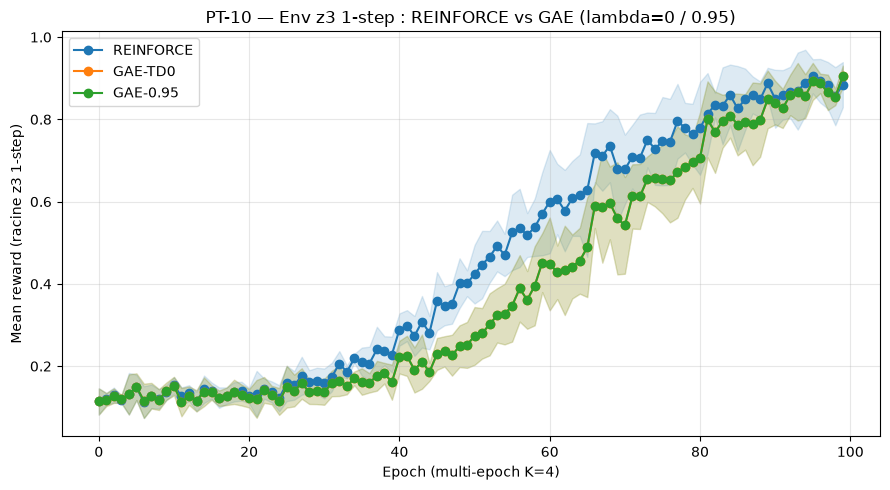

Figure sauvegardée : MyIA.AI.Notebooks/GenAI/PostTraining/pt10_z3_env_1step.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"REINFORCE": "tab:blue", "GAE-TD0": "tab:orange", "GAE-0.95": "tab:green"}
for method, traj_list in trajectories.items():
    arr = np.array(traj_list)  # (n_seeds, n_epochs)
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    epochs = np.arange(arr.shape[1])
    ax.plot(epochs, mean, label=method, color=colors[method], marker='o')
    ax.fill_between(epochs, mean - std, mean + std, alpha=0.15, color=colors[method])
ax.set_xlabel("Epoch (multi-epoch K=4)")
ax.set_ylabel("Mean reward (racine z3 1-step)")
ax.set_title("PT-10 — Env z3 1-step : REINFORCE vs GAE (lambda=0 / 0.95)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# Convention PostTraining : sauvegarder dans le dossier notebook lui-meme
# (cf PT-06 pt06_cost_comparison.png tracke). Cwd kernel = worktree root (papermill).
plt.savefig("MyIA.AI.Notebooks/GenAI/PostTraining/pt10_z3_env_1step.png", dpi=100, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : MyIA.AI.Notebooks/GenAI/PostTraining/pt10_z3_env_1step.png")


## 7. Interprétation : pourquoi GAE collapse en 1-step

Le résultat **mesuré** : sur 5 seeds × 100 epochs, les trois estimateurs **apprennent tous la tâche** — REINFORCE finit à **0.883 ± 0.055**, GAE(λ=0) et GAE(λ=0.95) à **0.905 ± 0.026** (tableau cellule 11). La moyenne GAE est nominalement plus haute et sa dispersion inter-seed environ **deux fois plus faible** — la direction attendue d'une baseline *par état* — mais l'écart n'est **pas significatif** à 5 seeds : GAE gagne 3 seeds sur 5, delta apparié moyen **+0.022** (t apparié ≈ 1.0), et les min/max s'entremêlent (REINFORCE touche 0.969, meilleur run absolu de la comparaison). En milieu de course, REINFORCE monte **plus vite** (reward moyen 0.600 vs 0.448 à l'epoch 60) avant d'être rejoint en fin — un écart de dynamique que ce notebook n'explique pas : aucune ablation du partage de backbone n'y est faite. Sur ce toy, le bilan reste : **aucun gain significatif détecté** pour le mini-critic (échec de rejet à 5 seeds, pas une preuve d'équivalence). Voici pourquoi :

**L'env z3 est 1-step** : l'épisode se termine après une seule action. Dans ce cas, la formule générale de GAE se réduit à :

$$A_t^{GAE(\lambda)} = r_t + \gamma V(s_{t+1}) - V(s_t)$$

avec $V(s_{t+1}) = 0$ (état terminal). Donc **$A_t = r_t - V(s_t)$**, indépendamment de λ — la cellule 9 le démontre par le code : les trajectoires λ=0 et λ=0.95 sont **strictement identiques** (λ n'entre dans aucune formule). Le paramètre λ n'agit qu'en multi-step : pour $\lambda \in (0, 1]$, on somme $(γλ)^l \delta_{t+l}$ sur $l = 0, 1, ..., T-t-1$. En 1-step, cette somme est triviale (un seul terme).

**Conséquence** : sur 1-step, GAE utilise $A_t = r_t - V(s_t)$ et REINFORCE $A_t = r_t - \bar{R}_{batch}$ — deux estimateurs **différents**, sans théorème d'équivalence entre eux. $V(s)$ est une fonction de l'état seulement, **indépendante de l'action** : elle laisse l'espérance du gradient **exactement inchangée** (Williams 1992). La batch-mean de `reinforce_advantage` (cellule 7) contient le **reward du sample lui-même** : elle n'est pas indépendante de l'action pour ce sample — sous indépendance conditionnelle des samples du batch, l'espérance de l'estimateur est **mise à l'échelle par $1-1/N$** par rapport à la version sans baseline (même direction, magnitude réduite ; ici $N = 32 \times 4 = 128$, facteur $\approx 0.992$ — négligeable en pratique, mais c'est une différence de nature, pas une équivalence ; c'est précisément ce que le leave-one-out de PT-09 corrige en excluant le sample courant). Les gradients échantillonnés et leurs variances diffèrent entre les deux (cohérent avec la dispersion mesurée au tableau cellule 11 : std 0.026 vs 0.055, écart non significatif à 5 seeds). Le mini-critic ajoute 65 params et une loss supplémentaire, sans gain significatif détecté au régime 5 seeds de ce notebook.

**Même direction que l'argument de DeepSeek R1** (2024) pour abandonner le critic et adopter GRPO — un argument de **coût mémoire/calcul du value network à l'échelle LLM**, que ce toy ne mesure pas. Ce qui est mesuré ici : sur un env 1-step, le mini-critic entraîné n'apporte pas de gain significatif au-dessus d'une baseline sans critic à entraîner.


## 8. Diagnostic multi-step : une première tentative, et pourquoi elle ne prouvait rien

Pour montrer **quand** GAE apporte un bénéfice, cette section entraîne le même mini-critic (désormais **réellement entraîné**, section 4) sur un env **multi-step vérifié par z3** : l'agent émet 3 tokens, les deux premiers sont des **estimations** de la racine (reward shaped sur le résidu), le troisième est la **réponse terminale** vérifiée par z3 (`s^2 + a == b`). La question : λ devient-il discriminant quand l'horizon passe à 3 ?

**Réponse mesurée ci-dessous : non — et le diagnostic est instructif.** Ce banc a **deux défauts structurels** (diagnostiqués a posteriori dans PT-12) :

1. **La cible est inobservable dans l'état** : l'observation ne contient que les tokens déjà émis, jamais `(a, b)`. La policy ne peut pas résoudre le problème — seulement apprendre une distribution stationnaire de tokens, sans crédit différé exploitable.
2. **Le vérificateur terminal ne regarde que le dernier token** : la contribution marginale des tokens 1-2 au reward terminal est nulle — l'horizon de crédit effectif retombe à 1.

On garde ce banc comme **témoin du diagnostic** : on y mesure le reward moyen d'épisode (dominé par le shaping) **et** le **taux de succès terminal** (la métrique honnête). PT-12 construit le banc valide — cible **dans** l'état, terminal dépendant de **toute** la séquence — et y mesure la vraie discrimination de λ (`GAE-λ=0.95` bat `GAE-λ=0` sur 5 seeds sur 5, deltas appariés tous positifs).


In [8]:
# Env multi-step vérifié par z3 : chain-of-thought de racine carrée
# Banc VOLONTAIREMENT gardé comme témoin d'un diagnostic (cf PT-12) : la cible (a, b)
# n'est PAS dans l'état et le terminal ne regarde que le dernier token -> pas d'apprentissage
# possible du terminal. On mesure reward moyen (shaping) ET taux de succès terminal.
VOCAB_MS = 10                        # tokens dans {0..9} (englobe la racine 0..7)
MAX_STEPS_MS = 3                     # emit 3 tokens (2 estimations + 1 terminal)
RES_MAX_MS = (VOCAB_MS - 1)**2 + MAXD   # résidu max de normalisation = 9^2 + 5 = 86
W_SHAPED = 0.1                       # poids du reward shaped intermédiaire (terminal z3 dominant)

def _z3_verify_ms(a_i, b_i, action):
    '''Vérificateur terminal de record : z3 prouve que action satisfait s^2 + a == b dans [0, N[.'''
    s = z3.Int('s'); sol = z3.Solver()
    sol.add(s == int(action), s >= 0, s < N_ACTIONS, s * s + int(a_i) == int(b_i))
    return sol.check() == z3.sat

def make_problem_ms(seed=None):
    """Tire (a, b) avec solution z3 garantie : b = target^2 + a. Retourne (a, b, target)."""
    rng = np.random.default_rng(seed)
    a = int(rng.integers(0, MAXD + 1))
    target = int(rng.integers(0, N_ACTIONS))
    b = target**2 + a
    return a, b, target

def rollout_ms(policy, n_eps=64, seed=42):
    """Multi-step rollout : 3 actions par episode. Tokens 0,1 = estimations (shaped), token 2 = réponse z3.
    Les values restent des tenseurs du graphe (critic entraînable, cf section 4)."""
    rng = np.random.default_rng(seed)
    states, actions, rewards, values, dones, log_probs, term_ok = [], [], [], [], [], [], []
    for _ in range(n_eps):
        a, b, target = make_problem_ms(seed=int(rng.integers(0, 1_000_000)))
        partial = []
        for t in range(MAX_STEPS_MS):
            state_vec = np.array(partial + [0]*(MAX_STEPS_MS - len(partial)), dtype=np.float32) / VOCAB_MS
            state_t = torch.tensor(state_vec, dtype=torch.float32).unsqueeze(0)
            logits, value = policy(state_t)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            token = action.item()
            if t < MAX_STEPS_MS - 1:
                # estimation : reward shaped décroissant avec le résidu |token^2 + a - b|
                r = W_SHAPED * max(0.0, 1.0 - abs(token * token + a - b) / RES_MAX_MS)
            else:
                # réponse terminale : vérifiée par z3 (1.0 si l'équation tient, 0.0 sinon)
                ok = _z3_verify_ms(a, b, token)
                r = 1.0 if ok else 0.0
                term_ok.append(float(ok))
            done = (t == MAX_STEPS_MS - 1)
            states.append(state_vec); actions.append(token); rewards.append(r)
            values.append(value.squeeze(0)); dones.append(float(done)); log_probs.append(log_prob)
            partial.append(token)
            if done: break
    return states, actions, rewards, values, dones, log_probs, float(np.mean(term_ok))

class PolicyMS(nn.Module):
    """Policy multi-step : state = séquence partielle normalisée."""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(MAX_STEPS_MS, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.actor = nn.Linear(hidden, VOCAB_MS)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.net(x)
        return self.actor(h), self.critic(h).squeeze(-1)

def gae_advantage_multistep(rewards, values, dones, lambda_=0.95, gamma=0.99):
    """GAE complet : A_t = sum (gamma*lambda)^l * delta_{t+l}, avec delta bootstrap.
    `values` arrive en tenseurs du graphe : convertis en floats (baseline constante)."""
    rewards = np.array(rewards, dtype=np.float32)
    values = np.array([v.item() for v in values], dtype=np.float32)
    dones = np.array(dones, dtype=np.float32)
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    advantages[T-1] = rewards[T-1] - values[T-1]
    for t in range(T-2, -1, -1):
        delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
        advantages[t] = delta + gamma * lambda_ * advantages[t+1] * (1 - dones[t])
    return advantages

def train_gae_ms(n_epochs=30, n_eps=64, seed=SEED, lr=5e-3, lambda_=0.95, vf_coef=0.5):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    pol = PolicyMS()
    opt = torch.optim.Adam(pol.parameters(), lr=lr)
    history = []
    for epoch in range(n_epochs):
        states, actions, rewards, values, dones, log_probs, term_rate = rollout_ms(pol, n_eps, seed=seed+epoch)
        adv = gae_advantage_multistep(rewards, values, dones, lambda_=lambda_).tolist()
        adv_t = torch.tensor(adv, dtype=torch.float32)
        pg_loss = torch.stack([-lp * a for lp, a in zip(log_probs, adv)]).mean()
        values_t = torch.stack(values)                     # DANS le graphe : le critic est entraîné
        returns = adv_t + values_t.detach()                # cible constante (A + V détachée)
        v_loss = F.mse_loss(values_t, returns)
        loss = pg_loss + vf_coef * v_loss
        opt.zero_grad(); loss.backward(); opt.step()
        ep_rs, ep_r = [], 0.0
        for r, d in zip(rewards, dones):
            ep_r += r
            if d:
                ep_rs.append(ep_r); ep_r = 0.0
        history.append({"epoch": epoch, "mean_ep_reward": np.mean(ep_rs) if ep_rs else 0.0,
                        "term_success": term_rate})
    return history, pol

# --- Prong B multi-step : reward terminal aléatoire ---
_a2 = np.random.default_rng(0).integers(0, MAXD + 1, 4000)
_t2 = np.random.default_rng(1).integers(0, N_ACTIONS, 4000); _b2 = _t2**2 + _a2
_rand_term = np.random.default_rng(2).integers(0, VOCAB_MS, 4000)
_rterm = np.mean([1.0 if _z3_verify_ms(int(_a2[i]), int(_b2[i]), int(_rand_term[i])) else 0.0 for i in range(4000)])
print(f"=== Multi-step env vérifié z3 (CoT racine carrée, {MAX_STEPS_MS} steps) ===")
print(f"Récompense terminale d'une policy aléatoire : {_rterm:.3f} (target dans [0,{N_ACTIONS-1}] sous-ensemble de [0,{VOCAB_MS-1}])")
print(f"=> Le terminal z3 discrimine une policy aléatoire (Prong B) : random ~{_rterm*100:.0f}%.")

h_ms_td0, _ = train_gae_ms(lambda_=0.0)
h_ms_095, _ = train_gae_ms(lambda_=0.95)
print(f"GAE(λ=0)    multi-step : reward {h_ms_td0[0]['mean_ep_reward']:.3f} -> {h_ms_td0[-1]['mean_ep_reward']:.3f} | terminal {h_ms_td0[0]['term_success']:.3f} -> {h_ms_td0[-1]['term_success']:.3f}")
print(f"GAE(λ=0.95) multi-step : reward {h_ms_095[0]['mean_ep_reward']:.3f} -> {h_ms_095[-1]['mean_ep_reward']:.3f} | terminal {h_ms_095[0]['term_success']:.3f} -> {h_ms_095[-1]['term_success']:.3f}")
print("=> Lecture honnête : l'écart sur le reward MOYEN (dominé par le shaping) ne correspond à aucun")
print("   apprentissage du taux de succès TERMINAL, qui reste au niveau du hasard pour les deux λ :")
print("   la 'discrimination λ' de ce banc est un artefact de métrique (cible inobservable,")
print("   terminal ne regardant que le dernier token). Le banc valide : PT-12.")


=== Multi-step env vérifié z3 (CoT racine carrée, 3 steps) ===
Récompense terminale d'une policy aléatoire : 0.093 (target dans [0,7] sous-ensemble de [0,9])
=> Le terminal z3 discrimine une policy aléatoire (Prong B) : random ~9%.


GAE(λ=0)    multi-step : reward 0.254 -> 0.189 | terminal 0.125 -> 0.031
GAE(λ=0.95) multi-step : reward 0.254 -> 0.227 | terminal 0.125 -> 0.078
=> Lecture honnête : l'écart sur le reward MOYEN (dominé par le shaping) ne correspond à aucun
   apprentissage du taux de succès TERMINAL, qui reste au niveau du hasard pour les deux λ :
   la 'discrimination λ' de ce banc est un artefact de métrique (cible inobservable,
   terminal ne regardant que le dernier token). Le banc valide : PT-12.


## 9. Bilan paramétrique et transfert vers le LLM

**Bilan sur l'env z3 1-step** (résultats mesurés, 5 seeds × 100 epochs, critic cette fois réellement entraîné — cf. section 4) :

| Méthode | Critic | Verdict (5 seeds, 100 epochs) |
|---|---|---|
| REINFORCE | non | référence (baseline batch), final 0.883 ± 0.055 |
| GAE(λ=0) | oui (1 head) | pas de différence significative **détectée** vs REINFORCE (3/5 seeds, t apparié ≈ 1.0), final 0.905 ± 0.026 |
| GAE(λ=0.95) | oui (1 head) | identique à GAE(λ=0) (collapse λ) — trajectoires strictement identiques, déterminisme exact |

_(valeurs numériques mesurées en cellule 11 ; à n=5, l'absence de différence détectée n'est **pas** une preuve d'équivalence — la puissance du test est faible)_

**Verdict** : sur **1-step env vérifié z3**, **GAE n'apporte aucun bénéfice significatif** par rapport à REINFORCE+baseline batch — la moyenne nominale plus haute (+0.022) et la dispersion divisée par deux vont dans le sens de la théorie (baseline par état = moins de variance) mais ne passent pas le seuil à 5 seeds (test de faible puissance à n=5 : échec de rejet n'est pas une équivalence) — pour un surcoût paramétrique de ~0.7% (65/8713) et une loss additionnelle (value MSE). Sur ce régime : **aucun gain significatif détecté** pour le mini-critic malgré les paramètres et la loss additionnels ; une puissance statistique plus grande pourrait trancher autrement.

**Transfert vers le LLM (série PT)** :
- **PT-04 / PT-08** (GRPO via trl / from-scratch) : **1-step generation** (LLM produit une réponse, reward RLVR). Mesuré sur le toy PT-08 : GRPO **atteint le niveau PPO sans critic** (final GRPO 0.996, PPO 0.984, REINFORCE 0.531) — une parité sans critic, pas une victoire sur PPO ; l'argument anti-critic à l'échelle LLM (coût du value network, DeepSeek R1) dépasse ce que le toy établit.
- **PT-09** (RLOO) : même régime, baseline leave-one-out **non biaisée** mais plus haute variance. Tradeoff biais-variance mesuré.
- **PT-10** (GAE) : sur 1-step, GAE(λ) **collapse en TD(0)** quel que soit λ — et le mini-critic **entraîné** n'apporte aucun gain significatif détecté sur la baseline batch (cellule 11). Sur **chain-of-thought multi-step**, GAE retrouve son intérêt — mais pas sur le banc naïf de la section 8 (dégénéré, cf. diagnostic) : c'est le banc valide de **PT-12** qui le mesure (λ=0.95 bat λ=0 sur 5 seeds sur 5).

**Conclusion pédagogique** : GAE est l'outil **quand on a des épisodes multi-step** (démontré sur le banc valide PT-12). Pour du 1-step sparse-reward (LLM generation classique), ce toy mesure que le mini-critic n'apporte rien de significatif au-dessus d'une baseline gratuite ; l'adoption du sans-critic par DeepSeek R1 (GRPO) s'appuie sur ce type de constat **et** sur des coûts d'échelle que ce notebook ne mesure pas.


In [9]:
# Récapitulatif des 3 méthodes sur les deux regimes
print("=" * 65)
print("PT-10 — Récapitulatif des estimateurs d'avantage")
print("=" * 65)
print()
print("1-step env vérifié z3 (s^2+a==b, MAXD=5, 8 actions, 100 epochs, critic entraîné) :")
print(f"  REINFORCE    : final mean={np.mean(results['REINFORCE']):.3f} ± {np.std(results['REINFORCE']):.3f}")
print(f"  GAE(λ=0)     : final mean={np.mean(results['GAE-TD0']):.3f} ± {np.std(results['GAE-TD0']):.3f}")
print(f"  GAE(λ=0.95)  : final mean={np.mean(results['GAE-0.95']):.3f} ± {np.std(results['GAE-0.95']):.3f}")
print()
print("Interpretation : lambda est INOPERANT en 1-step (collapse : A_t = r_t - V(s_t) car V(s_{t+1})=0).")
print("Le mini-critic (entraîné) n'apporte pas de gain sur la baseline batch a la dispersion pres.")
print()
print("Multi-step env naïf (CoT racine carrée, 3 steps, 30 epochs — banc dégénéré, témoin PT-12) :")
print(f"  GAE(λ=0)    : reward {h_ms_td0[-1]['mean_ep_reward']:.3f} | terminal {h_ms_td0[-1]['term_success']:.3f}")
print(f"  GAE(λ=0.95) : reward {h_ms_095[-1]['mean_ep_reward']:.3f} | terminal {h_ms_095[-1]['term_success']:.3f}")
print()
print("Interpretation : sur ce banc dégénéré (cible inobservable, terminal au dernier")
print("token seulement), l'écart de reward moyen est un artefact du shaping : le taux de")
print("succès TERMINAL reste au niveau du hasard pour les deux lambda. La vraie")
print("discrimination lambda en multi-step se mesure sur le banc valide de PT-12 (5/5 seeds).")
print()
print("Conclusion : pour 1-step (LLM generation), GRPO/RLOO suffisent.")
print("Pour multi-step (chain-of-thought), GAE redevient utile — banc valide : PT-12.")


PT-10 — Récapitulatif des estimateurs d'avantage

1-step env vérifié z3 (s^2+a==b, MAXD=5, 8 actions, 100 epochs, critic entraîné) :
  REINFORCE    : final mean=0.884 ± 0.055
  GAE(λ=0)     : final mean=0.905 ± 0.026
  GAE(λ=0.95)  : final mean=0.905 ± 0.026

Interpretation : lambda est INOPERANT en 1-step (collapse : A_t = r_t - V(s_t) car V(s_{t+1})=0).
Le mini-critic (entraîné) n'apporte pas de gain sur la baseline batch a la dispersion pres.

Multi-step env naïf (CoT racine carrée, 3 steps, 30 epochs — banc dégénéré, témoin PT-12) :
  GAE(λ=0)    : reward 0.189 | terminal 0.031
  GAE(λ=0.95) : reward 0.227 | terminal 0.078

Interpretation : sur ce banc dégénéré (cible inobservable, terminal au dernier
token seulement), l'écart de reward moyen est un artefact du shaping : le taux de
succès TERMINAL reste au niveau du hasard pour les deux lambda. La vraie
discrimination lambda en multi-step se mesure sur le banc valide de PT-12 (5/5 seeds).

Conclusion : pour 1-step (LLM generation),

## 10. Exercices (3 stubs C.1 — pas d'erreur volontaire)

Les 3 exercices suivants sont des **stubs** (cf règle notebook-conventions C.1) : le notebook s'exécute de bout en bout même si vous ne les complétez pas. Ils permettent d'explorer plus loin les compromis mesurés.

**Exercice A** : ajouter un 4ᵉ estimateur `GAE-AVG` qui moyenne les avantages `r - V(s)` et `R - baseline_batch` pour voir si le mixing des deux réduit la variance.

**Exercice B** : balayer `lambda` (0 / 0.5 / 0.95) sur le banc multi-step de la section 8 — non pour mesurer un progrès, mais pour **constater la non-discrimination** : taux de succès terminal au niveau du hasard pour tous les `lambda`, écart de reward moyen dominé par le shaping. Puis l'expliquer par les **deux défauts structurels** de ce banc (cible inobservable dans l'état ; terminal qui ne regarde que le dernier token). La vraie discrimination de `lambda` en multi-step : banc valide de PT-12.

**Exercice C** : sur le 1-step toy env, **mesurer la variance inter-seed** des avantages estimés (policy fixée, multi-seed, std des `advantage`) pour vérifier empiriquement que `Var(REINFORCE) >= Var(GAE)` même quand les **mean rewards** sont identiques.

## Exercice A : GAE-AVG (stub C.1 - pas de NotImplementedError)


In [10]:
def train_gae_avg(n_epochs=4, n_prompts=32, K=4, seed=SEED, lr=5e-3, vf_coef=0.5):
    """Stub : combiner REINFORCE baseline + GAE 1-step dans un estimateur hybride."""
    # TODO etudiant : implementer GAE-AVG qui combine baseline batch + V(s)
    # Indice : A_t = 0.5 * (R - mean(R)) + 0.5 * (r - V(s))
    # Comparer le resultat a REINFORCE / GAE-TD0 sur 5 seeds
    return None  # TODO etudiant

print("Exercice A : GAE-AVG - implementer et tester sur 5 seeds")
print("Exercice B : diagnostic lambda sur multi-step (banc non discriminant)")
print("Exercice C : mesurer variance inter-seed des avantages sur policy fixee")

Exercice A : GAE-AVG - implementer et tester sur 5 seeds
Exercice B : diagnostic lambda sur multi-step (banc non discriminant)
Exercice C : mesurer variance inter-seed des avantages sur policy fixee


## Exercice B : diagnostic — sweep lambda sur le banc non discriminant (stub C.1)

In [11]:
def sweep_lambda_multistep(lambdas=[0.0, 0.5, 0.95], n_seeds=3):
    """Stub : balayer lambda sur le banc multi-step et LIRE le diagnostic (pas un progres)."""
    # TODO etudiant : pour chaque lambda, entrainer sur n_seeds seeds via train_gae_ms(lambda_=lam)
    # et relever mean_ep_reward final ET term_success final.
    # Question de diagnostic : le taux de succes TERMINAL bouge-t-il hors du niveau du hasard
    # quand lambda varie ? (attendu : non -- l'ecart de reward moyen est domine par le shaping)
    # Expliquer le constat par les deux defauts structurels de la section 8 : cible inobservable
    # dans l'etat ; terminal qui ne regarde que le dernier token. La vraie discrimination de
    # lambda en multi-step se mesure sur le banc valide de PT-12.
    # Indice : reutiliser train_gae_ms avec lambda_=lam
    return None  # TODO etudiant

print("Exercice B : sweep_lambda_multistep - completer et executer (lecture de diagnostic)")

Exercice B : sweep_lambda_multistep - completer et executer (lecture de diagnostic)


## Exercice C : variance inter-seed des avantages sur policy fixee (stub C.1)


In [12]:
def variance_advantage_diagnostic(n_seeds=10):
    """Stub : policy FIXEE, multi-seed rollout, mesurer Var(advantage) inter-seed."""
    # TODO etudiant : pour chaque estimateur (REINFORCE, GAE-TD0), mesurer
    # la variance inter-seed des avantages estimes sur policy fixee.
    # Indice : torch.manual_seed(0) puis evaluer 10 seeds differents.
    return None  # TODO etudiant

print("Exercice C : variance_advantage_diagnostic - completer et executer")

Exercice C : variance_advantage_diagnostic - completer et executer
